In [44]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters 

In [45]:
dt = 0.01  # time step
g = 9.8    #gravity 
k = 0.1   # air resistance drag
mx_steps = 10000
steps = 0

In [46]:
v0 = 10   # initial speed
theta = 45 # lauch angel 


In [47]:
if dt <= 0:
    raise VauleError("dt must be >0 ")
if k < 0:
    raise VauleError("K must be >= 0")

## Simulation

## Derived Parameters

In [48]:
theta_r = np.radians(theta)   #conver degree angle into radian
vx = v0 * np.cos(theta_r)     # velocity x component 
vy = v0 * np.sin(theta_r)     # velocity y component 

## Trejecotry without air drag ( Ideal Model ) 

In [49]:
x1,y1 = [0],[0]   #initial position 

while y1[-1] >= 0 and steps < mx_steps:     # till the vertical position greater then zero
    v = np.sqrt(vx**2 + vy**2)

    ax = 0      #horizental acceleration which os zero
    ay = -g     # verial acceleration provides by gravity 

    vx += ax * dt      #increasment in horizental component velocity with time
    vy += ay * dt      # increasment in vertical component velocity with time 

    x1.append(x1[-1] + vx*dt)      #increasment in horizental position with time
    y1.append(y1[-1] + vy*dt)      
    
    steps += 1
    

In [50]:
if steps == mx_steps:
    print("Loop stopped due to safety limit --- possiblie bug")

## Trejectory with air drag!

In [51]:
x2 , y2 = [0],[0]

while y2[-1] >= 0 and steps < mx_steps:
    
    v = np.sqrt(vx**2 + vy**2)

    ax =  -k * v * vx
    ay = -g - k* v * vy

    vx += ax * dt
    vy += ay * dt

    x2.append(x2[-1] + vx*dt)
    y2.append(y2[-1] + vy*dt)

    steps += 1

In [52]:
if steps == mx_steps:
    print("Loop stopped due to safety limit --- possiblie bug")

## Find the Time of flight of the object in projectile motion

In [90]:
def Time_of_flight(v0=20,theta=45,k=0.5,dt=0.005,steps=0):

    y = [0]
    t = 0
    theta_t = np.radians(theta)
    global mx_steps
    vx = v0 * np.cos(theta_t)
    vy = v0 * np.sin(theta_t)
    max_height = y[-1]

    while y[-1] >= 0 and steps < mx_steps:

    
        v = np.sqrt(vx**2 + vy**2)

        ax = -k * v * vx
        ay = -g - k* v * vy

        vx += ax * dt
        vy += ay * dt

        
        y.append(y[-1] + vy*dt)

        if y[-1] > max_height:
            max_height = y[-1]

        steps += 1
        t += dt
    
    if steps == mx_steps:
        print("ValueErro: Some bug is in the code!")

    return {
        "time": t,
        "height": max_height,
    }




## Variation of time of flight with different lauch angles 

In [107]:
theta_values = np.linspace(0,100,200)
Time = []

for s in theta_values:
    r = Time_of_flight(v0=20,theta=s)
    Time.append(r["time"])

  

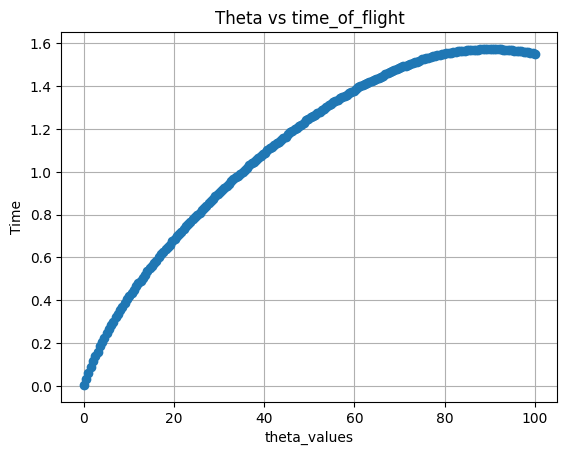

In [92]:
plt.plot(theta_values, Time , marker = 'o')
plt.xlabel("theta_values")
plt.ylabel("Time")
plt.title("Theta vs time_of_flight")

plt.grid()
plt.show()

## angle for which the time of flight is maximm!

In [106]:
max_time = max(Time)
index = np.argmax(Time)
optimal_angle = theta_values[index]

print(f"for angle {optimal_angle:.2f} the time of flight is maximum {max_time:.2f} second")

for angle 87.94 the time of flight is maximum 1.57 second


## Variation of flight of time with differe air drag coefficient 

In [93]:
k_values = np.linspace(0,0.10,10)
Time = []
Height = []

for s in k_values:
    r = Time_of_flight(v0=20,theta=45,k=s)
    Time.append(r["time"])
    Height.append(r["height"])
    print(f"k_values = {s:.2f}, time = {r['time']:.2f}, height = {r['height']:.2f}")

k_values = 0.00, time = 2.88, height = 10.17
k_values = 0.01, time = 2.65, height = 8.62
k_values = 0.02, time = 2.48, height = 7.59
k_values = 0.03, time = 2.35, height = 6.83
k_values = 0.04, time = 2.24, height = 6.24
k_values = 0.06, time = 2.15, height = 5.76
k_values = 0.07, time = 2.07, height = 5.37
k_values = 0.08, time = 2.00, height = 5.03
k_values = 0.09, time = 1.94, height = 4.75
k_values = 0.10, time = 1.89, height = 4.50


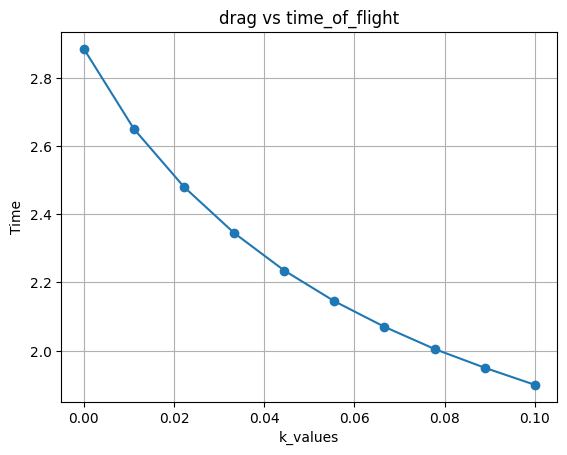

In [57]:
plt.plot(k_values, Time , marker = 'o')
plt.xlabel("k_values")
plt.ylabel("Time")
plt.title("drag vs time_of_flight")

plt.grid()
plt.show()